In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"pulsar_star.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [4]:
star_df = df[[" Mean of the integrated profile"," Standard deviation of the integrated profile", "target_class"]]
star_df

,Mean of the integrated profile,Standard deviation of the integrated profile,target_class
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [5]:
star_df.columns = ["signal_mean_power", "signal_spread", "target"]
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [6]:
# 1.0이 0.0에비해 10배나 적어서 편향된 결과를 가져올수도있음?
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

### 언더 샘플링(데이터 불균형 해결)

In [7]:
df_0 = star_df[star_df["target"] == 0]
df_1 = star_df[star_df["target"] == 1]

print(len(df_0), len(df_1))

df_0_sampled = df_0.sample(n=len(df_1), random_state=2026)
print(len(df_0_sampled))

11375 1153
1153


In [8]:
print(type(df_1), type(df_0_sampled))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>


In [69]:
star_df = pd.concat([df_1, df_0_sampled]).sample(frac=1, random_state=2026).reset_index(drop=True)
# .reset_index(drop=True) : 기존 인덱스 버리기

star_df.head()

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0.0
1,25.437500,38.225636,1.0
2,34.023438,32.876299,1.0
3,101.093750,47.496289,0.0
4,101.945312,39.955309,0.0


### 사이킷런 KNN 분류 사이클 실습

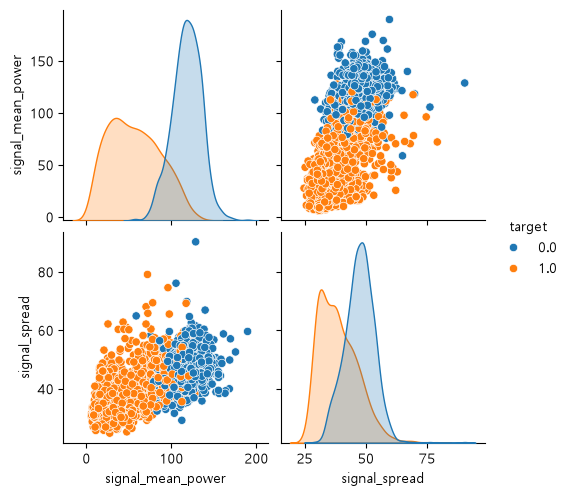

In [10]:
# 데이터 확인
sns.pairplot(star_df, hue="target")
plt.show()

In [11]:
# 데이터와 타켓 분리
X = star_df.drop("target", axis=1)
y = star_df["target"]

In [12]:
# 트레인,테스트 분리 ( 분리하는 이유. 데이터를 다 넘기면 그냥 모델이 외워버림. 일부만 주고 맞추게 해야함)
# 데이터가 과적합될수도있음. 다른질문이 들어왔을때 답이없어 답을 못하는 상황발생
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1844, 2) (462, 2) (1844,) (462,)


In [13]:
scaler = StandardScaler()

In [14]:
#표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#모델 생성
kn = KNeighborsClassifier()

In [16]:
#공부용 문제와 정답 넣기
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [17]:
#예측
y_pred = kn.predict(X_test_scaled)

In [18]:
#확인
print("학습데이터 점수")
print(kn.score(X_train_scaled, y_train))
print("테스트 점수")
print(kn.score(X_test_scaled, y_test))
print("정확도")
print(accuracy_score(y_test, y_pred))

학습데이터 점수
0.9181127982646421
테스트 점수
0.8917748917748918
정확도
0.8917748917748918


In [19]:
## 쌤풀이 @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@

## 1단계, 데이터 전처리
- 데이터 정보(info) : 결측치 여부 확인, 데이터 타입 확인 (수치형인지 분류형인지)
- 데이터 기술 통계량(describe) : 4분위수, 이상치 확인
- 데이터 EDA
- 데이터 결측치, 이상치 처리
- 표준화, 정규화

In [23]:
star_df.info()
# 타입 확인하고 수치형 데이터인지 분류형인지 확인. (float은 수치형?) -> target은 분류형임! (그래서 int로 바꿔줘야하는건지?)

<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  2306 non-null   float64
 1   signal_spread      2306 non-null   float64
 2   target             2306 non-null   float64
dtypes: float64(3)
memory usage: 54.2 KB


In [24]:
star_df.describe()

,signal_mean_power,signal_spread,target
count,2306.000000,2306.000000,2306.000000
mean,87.201340,42.994349,0.500000
std,39.140325,8.200844,0.500108
min,5.812500,24.772042,0.000000
25%,54.300781,36.709625,0.000000
50%,96.570312,43.612955,0.500000
75%,118.986328,49.000045,1.000000
max,189.734375,90.250557,1.000000


In [27]:
# 1. 신호의 평균 세기가 작은 값이 진짜 별.
print(star_df.iloc[star_df["signal_mean_power"].idxmin()])
# 2. 신호의 평균 세기가 큰 값이 우주 잡음.
print(star_df.iloc[star_df["signal_mean_power"].idxmax()])

signal_mean_power     5.812500
signal_spread        30.631313
target                1.000000
Name: 557, dtype: float64
signal_mean_power    189.734375
signal_spread         59.578268
target                 0.000000
Name: 383, dtype: float64


In [29]:
# 타켓의 타입을 변경해서 좀 더 편리한 데이터로 변경
star_df["target"] = star_df["target"].astype(int)

In [30]:
star_df

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0
1,25.437500,38.225636,1
2,34.023438,32.876299,1
3,101.093750,47.496289,0
4,101.945312,39.955309,0
...,...,...,...
2301,155.460938,39.429506,0
2302,126.000000,45.366046,0
2303,40.062500,30.721722,1
2304,40.929688,30.200937,1


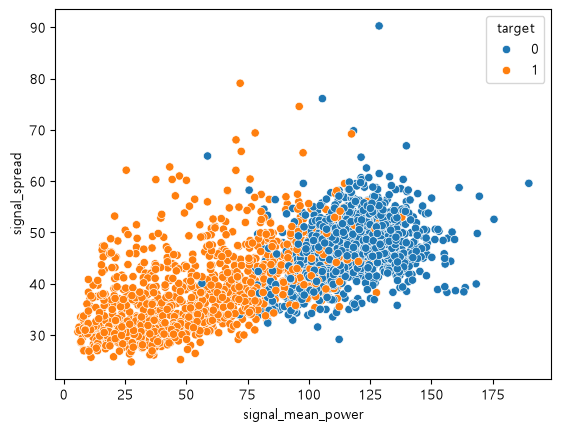

In [32]:
sns.scatterplot(star_df, x="signal_mean_power", y="signal_spread", hue="target")
plt.show()

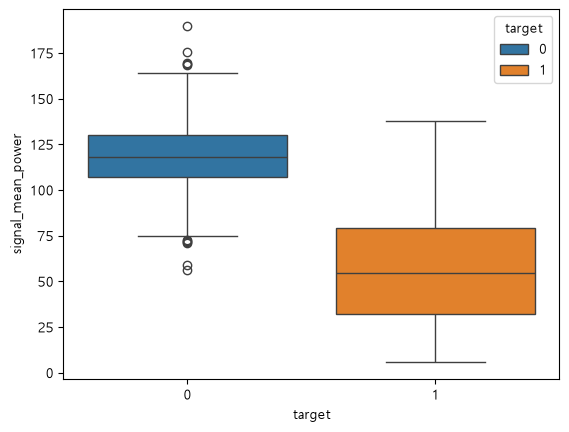

In [38]:
# signal_mean_power
sns.boxplot(star_df, x="target", y="signal_mean_power", hue="target")
plt.show()

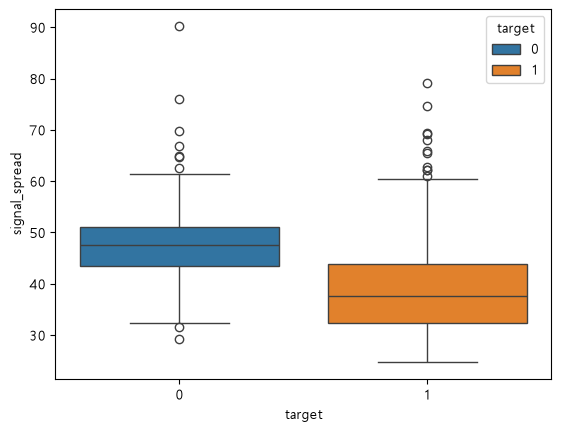

In [39]:
# signal_spread
sns.boxplot(star_df, x="target", y="signal_spread", hue="target")
plt.show()

### 독립변수와 종속변수 준비

In [42]:
X = star_df.drop("target", axis=1)
print(X.head())
y = star_df["target"]
print(y.head())

   signal_mean_power  signal_spread
0         138.820312      49.549602
1          25.437500      38.225636
2          34.023438      32.876299
3         101.093750      47.496289
4         101.945312      39.955309
0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64


In [43]:
#데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1844, 2) (462, 2) (1844,) (462,)


In [44]:
scaler = StandardScaler()
# 1. 스케일 하고 나누기 (똑같을거같다고 생각하지만 이렇게 하면 안됨. 데이터 누수가 생김)
# 2. 나누고 스케일 하기 (이게 원칙임)

#표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 평균으로부터 얼마나 떨어졌는지 나타낸 값
X_train_scaled

array([[ 0.860412  ,  0.06373395],
       [-0.04156142, -0.42246395],
       [ 0.83172734, -0.72122983],
       ...,
       [ 0.32894887,  0.84999533],
       [-0.86226162, -1.22677755],
       [ 1.43271095,  0.12325785]], shape=(1844, 2))

## 2단계, 모델 준비

## 하이퍼 파라미터(Hyper Parameter)
- 사람(개발자 또는 분석가)가 필요에 따라 직접 설정하는 파라미터의 값을 의미한다

## 파라미터(Parameter)
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미한다

In [46]:
kn = KNeighborsClassifier(n_neighbors=5)

## 3단계, 모델 학습

In [47]:
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [50]:
# 모델 예측
y_pred = kn.predict(X_test_scaled)
y_pred[:10]

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1])

In [53]:
print(f"모델 정확도 점수: {accuracy_score(y_pred, y_test)}")

모델 정확도 점수: 0.8917748917748918


In [59]:
# 1~20 까지 n_neighbors개수 중 최적의 개수 찾기

train_scores = []
test_scores = []

for k in range(1, 21):
    kn = KNeighborsClassifier(n_neighbors=k)
    kn.fit(X_train_scaled, y_train)

    train_scores.append(kn.score(X_train_scaled, y_train))
    test_scores.append(kn.score(X_test_scaled, y_test))


print(train_scores)
print(test_scores)

[1.0, 0.9235357917570499, 0.9273318872017353, 0.9126898047722343, 0.9181127982646421, 0.9094360086767896, 0.9061822125813449, 0.9072668112798264, 0.9072668112798264, 0.9045553145336226, 0.903470715835141, 0.9023861171366594, 0.9040130151843818, 0.9029284164859002, 0.903470715835141, 0.903470715835141, 0.903470715835141, 0.9013015184381779, 0.9029284164859002, 0.9029284164859002]
[0.8463203463203464, 0.8658008658008658, 0.8722943722943723, 0.8787878787878788, 0.8917748917748918, 0.8917748917748918, 0.8939393939393939, 0.8917748917748918, 0.8939393939393939, 0.8961038961038961, 0.8982683982683982, 0.8939393939393939, 0.8961038961038961, 0.8917748917748918, 0.8961038961038961, 0.9004329004329005, 0.9004329004329005, 0.9004329004329005, 0.8961038961038961, 0.8982683982683982]


In [61]:
train_k = train_scores.index(max(train_scores)) + 1
test_k = test_scores.index(max(test_scores)) + 1

print(f"훈련 데이터셋의 최적의 K의 개수 : {train_k}개")
print(f"테스트 데이터셋의 최적의 K의 개수 : {test_k}개")

훈련 데이터셋의 최적의 K의 개수 : 1개
테스트 데이터셋의 최적의 K의 개수 : 16개


In [64]:
new_data = pd.DataFrame([[50, 60]], columns=["signal_mean_power", "signal_spread"])
new_data_scaled = scaler.transform(new_data)
new_data_scaled

array([[-0.9522996,  2.1075871]])

In [65]:
distance, indexs = kn.kneighbors(new_data_scaled)
distance, indexs

(array([[0.14349252, 0.1522329 , 0.38340163, 0.44379392, 0.48164563,
         0.54441506, 0.5785064 , 0.60211116, 0.64451649, 0.67791605,
         0.6886558 , 0.76642106, 0.78381163, 0.81218364, 0.83059155,
         0.83890081, 0.91526352, 0.91665189, 0.92678993, 0.94649019]]),
 array([[1839, 1794,  326,  899, 1419, 1838,  642,  601, 1278, 1384, 1484,
          245,  811, 1736, 1002,  276,  452, 1263,  506, 1781]]))

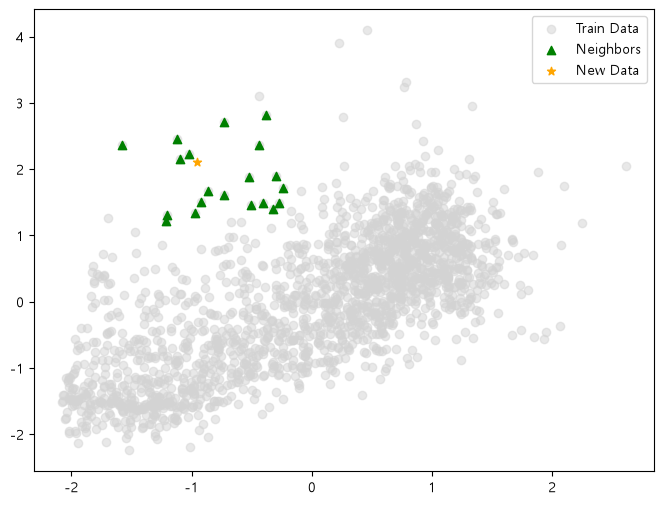

In [75]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c="lightgray", label="Train Data", alpha=0.5)

neighbor_data = X_train_scaled[indexs[0]]
plt.scatter(neighbor_data[:, 0], neighbor_data[:, 1], marker="^", color="green", label="Neighbors")
plt.scatter(new_data_scaled[0, 0], new_data_scaled[0, 1], marker="*", color="orange", label="New Data")
plt.legend()
plt.show()

# 저 별의 위치와 근접한 20개 잘 구해왔는지 시각화한것

In [76]:
kn.predict(new_data_scaled)

array([1])

## 4단계, 모델평가

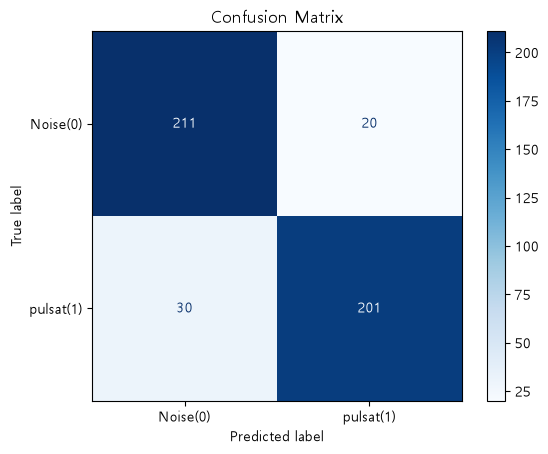

In [82]:
cm = confusion_matrix(y_test, y_pred)
cm
#이거 그거임 tp fp그 예측한거 맞췃을때. 예측햇는데 틀렷을때 어쩌구 그거 확인하는거

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Noise(0)", "pulsat(1)"])
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [85]:
# 이거로 확인해도댐
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       231
           1       0.91      0.87      0.89       231

    accuracy                           0.89       462
   macro avg       0.89      0.89      0.89       462
weighted avg       0.89      0.89      0.89       462

